<a href="https://colab.research.google.com/github/swirty/csc591-Hybrid-DL-ML-Classifier/blob/main/DL_ML_Hybrid_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# run to sync files into G drive!
# ONLY USE IF GOOGLE DRIVE IS NOT SYNCING LOCAL FILES OUT

from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Load Greyscale Images (Dataset Import)


In [ ]:
# Define basic dataset consts

import os
import shutil # Import shutil

# Define the source directory on Google Drive
drive_dataset_dir = '/content/drive/MyDrive/Colab-Hybrid-Ransomware'

# Define the local destination directory
local_dataset_dir = '/content/dataset'

copy_to_local = True

In [ ]:
# This is copying to the local fs in parallel
# Google drive does not tolerate streaming many small files quickly, frontload the work before training.

if copy_to_local:
  # Create the local dataset directory if it doesn't exist
  os.makedirs(local_dataset_dir, exist_ok=True)
  print(f"Created local dataset directory: {local_dataset_dir}")

  # Copy 'malware' directory
  drive_malware_dir = os.path.join(drive_dataset_dir, 'malware/')
  local_malware_dir = os.path.join(local_dataset_dir, 'malware/')
  if os.path.exists(drive_malware_dir) and not os.path.exists(local_malware_dir):
      print(f"Copying '{drive_malware_dir}' to '{local_malware_dir}'...")
      #shutil.copytree(drive_malware_dir, local_malware_dir)
      !mkdir -p {local_malware_dir}
      !cd {drive_malware_dir}; find . -print0 | xargs -0 -I $ -P 32 rsync -aR $ {local_malware_dir} # PARALLEL COPY -P is # of procs
      print("Malware directory copied.")
  elif os.path.exists(local_malware_dir):
      print(f"Malware directory already exists at {local_malware_dir}. Skipping copy.")
  else:
      print(f"Source malware directory not found: {drive_malware_dir}")

  # Copy 'benign' directory
  drive_benign_dir = os.path.join(drive_dataset_dir, 'benign/')
  local_benign_dir = os.path.join(local_dataset_dir, 'benign/')
  if os.path.exists(drive_benign_dir) and not os.path.exists(local_benign_dir):
      print(f"Copying '{drive_benign_dir}' to '{local_benign_dir}'...")
      #shutil.copytree(drive_benign_dir, local_benign_dir)
      !mkdir -p {local_benign_dir}
      !cd {drive_benign_dir}; find . -print0 | xargs -0 -I $ -P 32 rsync -aR $ {local_benign_dir} # PARALLEL COPY -P is # of procs
      print("Benign directory copied.")
  elif os.path.exists(local_benign_dir):
      print(f"Benign directory already exists at {local_benign_dir}. Skipping copy.")
  else:
      print(f"Source benign directory not found: {drive_benign_dir}")

Created local dataset directory: /content/dataset
Copying '/content/drive/MyDrive/Colab-Hybrid-Ransomware/malware/' to '/content/dataset/malware/'...
Malware directory copied.
Copying '/content/drive/MyDrive/Colab-Hybrid-Ransomware/benign/' to '/content/dataset/benign/'...
Benign directory copied.


In [ ]:
# Traverse the dataset

# Now, set the base_dir to the local dataset for subsequent image processing
base_dir = local_dataset_dir if copy_to_local else drive_dataset_dir
print(f"Using base directory: {base_dir}")
malware_dir = os.path.join(base_dir, 'malware')
benign_dir = os.path.join(base_dir, 'benign')

images = []
true_labels = []
restriction_count = None # Set a restriction count for faster epochs

# Process malware images
for sub_dir_name in os.listdir(malware_dir):
    current_dir_path = os.path.join(malware_dir, sub_dir_name)
    if os.path.isdir(current_dir_path):
        for image_name in os.listdir(current_dir_path):
            image_path = os.path.join(current_dir_path, image_name)
            if restriction_count is not None and len(images) >= restriction_count/2:
                break
            if os.path.isfile(image_path):
                print(f"Processing image: {image_path}")
                images.append(image_path)
                true_labels.append('1')

# Process benign images
for sub_dir_name in os.listdir(benign_dir):
    current_dir_path = os.path.join(benign_dir, sub_dir_name)
    if os.path.isdir(current_dir_path):
        for image_name in os.listdir(current_dir_path):
            image_path = os.path.join(current_dir_path, image_name)
            if restriction_count is not None and len(images) >= restriction_count:
                break
            if os.path.isfile(image_path):
                print(f"Processing image: {image_path}")
                images.append(image_path)
                true_labels.append('0')

print(f"Found {len(images)} images.")
print(f"Found {len(true_labels)} labels.")
# print(f"First 5 image paths: {images[:5]}")
# print(f"First 5 true labels: {true_labels[:5]}")

In [ ]:
# Build a loader for the dataset

import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import torch

# Set this to None to prevent DecompressionBombError for large images
Image.MAX_IMAGE_PIXELS = None

# Define the target image size
target_size = (256, 256)

def repeat_channel_three_times(x):
    if x.size(0) == 1:
        return x.repeat(3, 1, 1)
    return x

# Create a torchvision.transforms.Compose object
transform = transforms.Compose([
    # Convert the PIL Image to a PyTorch tensor using transforms.ToTensor().
    transforms.ToTensor(),
    # Use the named function to convert single-channel (greyscale)
    # images to 3-channel images by repeating the single channel three times
    transforms.Lambda(repeat_channel_three_times),
    # Resize
    transforms.Resize(target_size, antialias=True)
])

# Custom Dataset class for loading images on demand
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Open image and ensure it's in RGB format (3 channels)
        image = Image.open(img_path).convert('RGB')
        label = int(self.labels[idx]) # Ensure label is an integer

        if self.transform:
            image = self.transform(image)

        return image, label

# Convert true_labels to NumPy array
true_labels_np = np.array(true_labels, dtype=int)

# Create custom dataset using the image paths and labels
full_dataset = ImageDataset(images, true_labels_np, transform=transform)

print("ImageDataset class and transformations defined.")

ImageDataset class and transformations defined.


In [ ]:
# Split the dataset
import torch

# Define train and test split ratio
test_split_ratio = 0.3
dataset_size = len(full_dataset)
test_size = int(test_split_ratio * dataset_size)
train_size = dataset_size - test_size

# Split the dataset into training and testing sets
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(f"Dataset split into training size: {train_size} and testing size: {test_size}")

Dataset split into training size: 150783 and testing size: 64621


## Train CNN or Import ResNet50

In [ ]:
# Which NN to train
NeuralNetwork = 'ResNet50' # 'CNN' or 'ResNet50'

In [ ]:
# Model Definition For CNN
# See https://github.com/buildingmalwaredataset/models/blob/main/baseline_CNN_model

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch.nn as nn

class ConvNet(nn.Module):
    def __init__(self, num_classes=110):
        super(ConvNet, self).__init__()

        self.features = torch.nn.Sequential(

            nn.Conv2d(3, 224, kernel_size=11, stride=2, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(224, 192, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        # Define the part of the classifier that produces the 4096-dim feature vector
        self.feature_extractor_head = torch.nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU()
        )

        # Define the rest of the classifier for final predictions
        self.classification_head = torch.nn.Sequential(
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x, extract_features=False):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) # This is the 9216-dim vector

        # Apply the feature extraction head
        extracted_4096_features = self.feature_extractor_head(x)

        if extract_features:
            return extracted_4096_features # Return the 4096-dimensional features
        else:
            # Continue with the classification head for normal prediction
            out = self.classification_head(extracted_4096_features)
            return out

print("ConvNet model defined.")

ConvNet model defined.


In [ ]:
# Model definition for ResNet50

import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

class ResNet50Model(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet50Model, self).__init__()
        # Load pre-trained ResNet50 model
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Freeze all parameters in the pre-trained model's feature extractor layers
        for name, param in self.resnet.named_parameters():
            if "fc" not in name:  # Freeze all layers except the final FC layer
                param.requires_grad = False

        num_ftrs_resnet = self.resnet.fc.in_features # This will be 2048 for ResNet50

        self.feature_extractor_head = nn.Sequential(
            nn.Dropout(),
            nn.ReLU()
        )

    def forward(self, x, extract_features=False):
        # Forward pass through ResNet's convolutional layers (features backbone)
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1) # This is the 2048-dimensional feature vector from ResNet's body

        # Apply the feature_extractor_head. The output will be 2048 dimensions.
        return self.feature_extractor_head(x)

print("ResNet50Model model defined.")

ResNet50Model model defined.


In [ ]:
## This Cell performs the training and makes the model accessible for future use

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import tqdm # Import tqdm for progress bar


# Set this to None to prevent DecompressionBombError for large images
Image.MAX_IMAGE_PIXELS = None

# Create custom dataset using the image paths and labels
full_dataset = ImageDataset(images, true_labels_np, transform=transform)

# Determine the number of classes from true_labels data
num_classes = len(np.unique(true_labels_np))
print(f"Detected {num_classes} classes from true_labels.")

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Instantiate the model with the correct number of output classes
model_conv = ConvNet(num_classes=num_classes) if NeuralNetwork == 'CNN' else ResNet50Model(num_classes=num_classes) if NeuralNetwork == 'ResNet50' else None

# Check for GPU availability and move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_conv.to(device)
print(f"Using device: {device}")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_conv.parameters(), lr=0.001)

# Create DataLoader for training and testing
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=32)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, num_workers=32) # No need to shuffle test data

if NeuralNetwork == 'CNN':
    # Train the model
    num_epochs = 30 # Number of training epochs, adjust as needed
    print(f"Starting {NeuralNetwork} model training for {num_epochs} epochs...")

    # Lists to store metrics for plotting
    epoch_train_losses = []
    epoch_train_accuracies = []
    epoch_val_losses = [] # New list for validation losses
    epoch_val_accuracies = [] # New list for validation accuracies

    for epoch in range(num_epochs):
        model_conv.train() # Set model to training mode
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        # Training loop
        for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model_conv(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_dataset)
        epoch_train_accuracy = correct_predictions / total_predictions

        epoch_train_losses.append(epoch_train_loss)
        epoch_train_accuracies.append(epoch_train_accuracy)

        # Validation loop
        model_conv.eval() # Set model to evaluation mode
        val_running_loss = 0.0
        val_correct_predictions = 0
        val_total_predictions = 0

        with torch.no_grad(): # Disable gradient calculation for validation
            for inputs, labels in tqdm.tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Validation)"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_conv(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total_predictions += labels.size(0)
                val_correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / len(test_dataset)
        epoch_val_accuracy = val_correct_predictions / val_total_predictions

        epoch_val_losses.append(epoch_val_loss)
        epoch_val_accuracies.append(epoch_val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_val_accuracy:.4f}")

    print(f"{NeuralNetwork} model training complete.")

    # Plotting the loss and accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), epoch_train_losses, label='Training Loss')
    plt.plot(range(1, num_epochs + 1), epoch_val_losses, label='Validation Loss', linestyle='--', color='red') # Plot validation loss
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{NeuralNetwork} Loss over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), epoch_train_accuracies, label='Training Accuracy', color='orange')
    plt.plot(range(1, num_epochs + 1), epoch_val_accuracies, label='Validation Accuracy', linestyle='--', color='green') # Plot validation accuracy
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{NeuralNetwork} Accuracy over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

elif NeuralNetwork == 'ResNet50':
    print(f"set pre-trained {NeuralNetwork} model to eval...")
    model_conv.eval() # Set model to evaluation mode

print("Training and testing datasets (train_dataset, test_dataset) are ready for feature extraction.")

Detected 2 classes from true_labels.
Train dataset size: 150783
Test dataset size: 64621
Using device: cuda
Evaluating pre-trained ResNet50 model...


Evaluation for ResNet50: 100%|██████████| 64/64 [01:51<00:00,  1.74s/it]

ResNet50 Evaluation Complete: Val Loss: 7.7941, Val Accuracy: 0.0000
Training and testing datasets (train_dataset, test_dataset) are ready for feature extraction.


In [ ]:
# Save the NN model

model_save_path = f"/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_model_full.pth"
torch.save(model_conv.state_dict(), model_save_path)
print(f"CNN model saved to {model_save_path}")

CNN model saved to /content/drive/MyDrive/Colab-Hybrid-Ransomware/ResNet50/ResNet50_model_full.pth


In [ ]:
# Reload the NN model

import torch

model_save_path = f'/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_model_full.pth'
num_classes = len(np.unique(true_labels_np))

model_conv = ConvNet(num_classes=num_classes) if NeuralNetwork == 'CNN' else ResNet50Model(num_classes=num_classes) if NeuralNetwork == 'ResNet50' else None
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_conv.to(device)

# Load the saved state dictionary
model_conv.load_state_dict(torch.load(model_save_path, map_location=device))
model_conv.eval() # Set the model to evaluation mode after loading

print(f"CNN model loaded successfully from {model_save_path}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 355MB/s]


CNN model loaded successfully from /content/drive/MyDrive/Colab-Hybrid-Ransomware/ResNet50/ResNet50_model_full.pth


In [ ]:
# Extract Features

import tqdm
import numpy as np

model_conv.eval()

# Create DataLoaders for feature extraction from train and test sets
train_inference_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)
test_inference_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

X_train_features = []
y_train_labels = []

# Extract features and labels from the training set
print("Extracting features from training set...")
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(train_inference_loader, desc="Extracting Train Features"):
        inputs = inputs.to(device)
        features = model_conv(inputs, extract_features=True)
        X_train_features.append(features.cpu().numpy())
        y_train_labels.append(labels.cpu().numpy()) # Store original labels for train set

X_test_features = []
y_test_labels = []

# Extract features and labels from the testing set
print("Extracting features from testing set...")
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_inference_loader, desc="Extracting Test Features"):
        inputs = inputs.to(device)
        features = model_conv(inputs, extract_features=True)
        X_test_features.append(features.cpu().numpy())
        y_test_labels.append(labels.cpu().numpy()) # Store original labels for test set

# Concatenate all batches of features and labels into single NumPy arrays
X_train_features = np.concatenate(X_train_features, axis=0)
y_train_labels = np.concatenate(y_train_labels, axis=0)

X_test_features = np.concatenate(X_test_features, axis=0)
y_test_labels = np.concatenate(y_test_labels, axis=0)

print(f"Successfully extracted features for {len(X_train_features)} training images.")
print(f"Shape of X_train_features: {X_train_features.shape}")
print(f"Shape of y_train_labels: {y_train_labels.shape}")

print(f"Successfully extracted features for {len(X_test_features)} testing images.")
print(f"Shape of X_test_features: {X_test_features.shape}")
print(f"Shape of y_test_labels: {y_test_labels.shape}")


Extracting features from training set...


Extracting Train Features: 100%|██████████| 589/589 [18:54<00:00,  1.93s/it]


Extracting features from testing set...


Extracting Test Features: 100%|██████████| 253/253 [08:19<00:00,  1.98s/it]


Successfully extracted features for 150783 training images.
Shape of X_train_features: (150783, 2048)
Shape of y_train_labels: (150783,)
Successfully extracted features for 64621 testing images.
Shape of X_test_features: (64621, 2048)
Shape of y_test_labels: (64621,)


## Train Classifier ML Models

In [ ]:
# The train_test_split is now handled during NN training and feature extraction.
# Assign the pre-split features and labels directly.

X_train = X_train_features
X_test = X_test_features
y_train = y_train_labels
y_test = y_test_labels

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (150783, 2048)
Shape of X_test: (64621, 2048)
Shape of y_train: (150783,)
Shape of y_test: (64621,)


DT Model

In [ ]:
# Load the Decision Tree model
import joblib

dt_model_save_path = f'/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_dt_model_full.joblib'
model_dt = joblib.load(dt_model_save_path)

print(f"Decision Tree model loaded successfully from {dt_model_save_path}")

Decision Tree model loaded successfully from /content/drive/MyDrive/Colab-Hybrid-Ransomware/ResNet50/ResNet50_dt_model_full.joblib


In [ ]:
# Train the DT
from sklearn.tree import DecisionTreeClassifier as dt

model_dt = dt(random_state=42)
model_dt.fit(X_train, y_train)

print("Decision Tree Model trained successfully.")

In [ ]:
# Save the DT
import joblib
import os

dt_model_save_path = f'/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_dt_model_full.joblib'

# Save the Decision Tree model
joblib.dump(model_dt, dt_model_save_path)

print(f"Decision Tree model saved to {dt_model_save_path}")

Decision Tree Model (Test) Accuracy: 0.9601
Decision Tree Model (Test) Precision: 0.9594
Decision Tree Model (Test) Recall: 0.9578
Decision Tree Model (Test) F1 Score: 0.9586

Decision Tree Model (Train) Accuracy: 0.9608
Decision Tree Model (Train) Precision: 0.9606
Decision Tree Model (Train) Recall: 0.9588
Decision Tree Model (Train) F1 Score: 0.9597


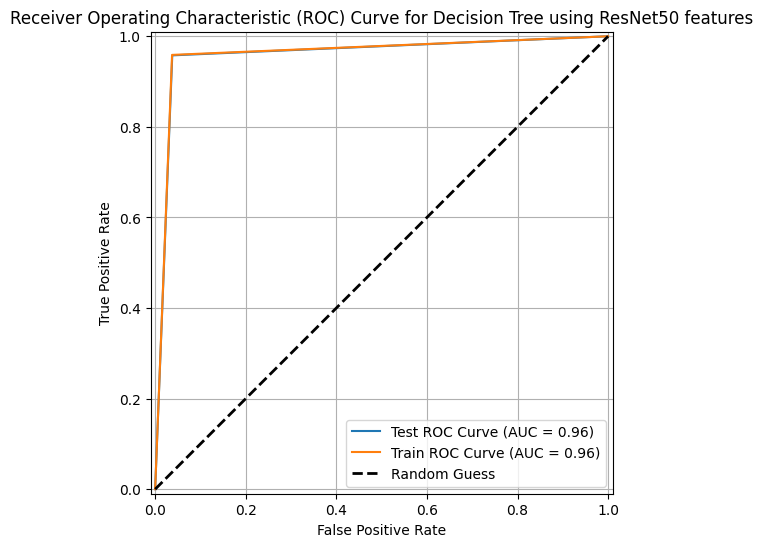

<Figure size 800x600 with 0 Axes>

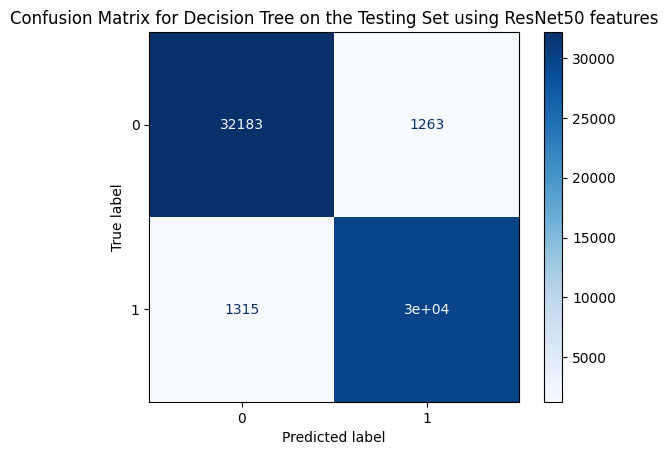

In [ ]:
# Do the analysis and make plots for DT
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# --- Test Set Metrics ---
y_pred_test = model_dt.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='binary', pos_label=1)
recall_test = recall_score(y_test, y_pred_test, average='binary', pos_label=1)
f1_test = f1_score(y_test, y_pred_test, average='binary', pos_label=1)

print(f"Decision Tree Model (Test) Accuracy: {accuracy_test:.4f}")
print(f"Decision Tree Model (Test) Precision: {precision_test:.4f}")
print(f"Decision Tree Model (Test) Recall: {recall_test:.4f}")
print(f"Decision Tree Model (Test) F1 Score: {f1_test:.4f}")

# --- Train Set Metrics ---
y_pred_train = model_dt.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train, average='binary', pos_label=1)
recall_train = recall_score(y_train, y_pred_train, average='binary', pos_label=1)
f1_train = f1_score(y_train, y_pred_train, average='binary', pos_label=1)

print(f"\nDecision Tree Model (Train) Accuracy: {accuracy_train:.4f}")
print(f"Decision Tree Model (Train) Precision: {precision_train:.4f}")
print(f"Decision Tree Model (Train) Recall: {recall_train:.4f}")
print(f"Decision Tree Model (Train) F1 Score: {f1_train:.4f}")

In [ ]:
# Plots for RF
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot ROC Curve
plt.figure(figsize=(8, 6))

# Get predicted probabilities for the positive class (TESTING SET)
y_pred_proba_test = model_dt.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC (TESTING SET)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_pred_proba_test, pos_label=1)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot the ROC curve (TESTING SET)
roc_display_test = RocCurveDisplay(fpr=fpr_test, tpr=tpr_test, roc_auc=roc_auc_test, estimator_name='Decision Tree (Test)')
roc_display_test.plot(ax=plt.gca(), name='Test ROC Curve')

# Get predicted probabilities for the positive class (TRAINING SET)
y_pred_proba_train = model_dt.predict_proba(X_train)[:, 1]

# Calculate ROC curve and AUC (TRAINING SET)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_proba_train, pos_label=1)
roc_auc_train = auc(fpr_train, tpr_train)

# Plot the ROC curve (TRAINING SET)
roc_display_train = RocCurveDisplay(fpr=fpr_train, tpr=tpr_train, roc_auc=roc_auc_train, estimator_name='Decision Tree (Train)')
roc_display_train.plot(ax=plt.gca(), name='Train ROC Curve')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess') # Add random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Decision Tree using {NeuralNetwork} features')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(model_dt, X_test, y_test, cmap=plt.cm.Blues, normalize=None)
cm_display.ax_.set_title(f'Confusion Matrix for Decision Tree on the Testing Set using {NeuralNetwork} features')
plt.show()

SVM Model


In [ ]:
# Load the SVM model
import joblib

svm_model_save_path = f'/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_svm_model_full.joblib'
model_svm = joblib.load(svm_model_save_path)

print(f"SVM model loaded successfully from {svm_model_save_path}")

SVM model loaded successfully from /content/drive/MyDrive/Colab-Hybrid-Ransomware/ResNet50/ResNet50_svm_model_full.joblib


In [ ]:
# Train the SVM
from sklearn.svm import SVC
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_svm = SVC(random_state=42, probability=True, verbose=True)

print("Starting SVM model training...")
model_svm.fit(X_train, y_train)
print("SVM model training complete.")

Starting SVM model training...
[LibSVM]SVM model training complete.


In [ ]:
# Save the SVM model
svm_model_save_path = f'/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_svm_model_full.joblib'

joblib.dump(model_svm, svm_model_save_path)

print(f"SVM model saved to {svm_model_save_path}")

In [ ]:
# Benchmark the SVM
# --- Test Set Metrics ---
y_pred_svm = model_svm.predict(X_test)
print("Predictions Made for Test Set")

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='binary', pos_label=1)
recall_svm = recall_score(y_test, y_pred_svm, average='binary', pos_label=1)
f1_svm = f1_score(y_test, y_pred_svm, average='binary', pos_label=1)

print(f"SVM Model (Test) Accuracy: {accuracy_svm:.4f}")
print(f"SVM Model (Test) Precision: {precision_svm:.4f}")
print(f"SVM Model (Test) Recall: {recall_svm:.4f}")
print(f"SVM Model (Test) F1 Score: {f1_svm:.4f}")

# --- Train Set Metrics ---
y_pred_svm_train = model_svm.predict(X_train)
print("\nPredictions Made for Train Set")

accuracy_svm_train = accuracy_score(y_train, y_pred_svm_train)
precision_svm_train = precision_score(y_train, y_pred_svm_train, average='binary', pos_label=1)
recall_svm_train = recall_score(y_train, y_pred_svm_train, average='binary', pos_label=1)
f1_svm_train = f1_score(y_train, y_pred_svm_train, average='binary', pos_label=1)

print(f"SVM Model (Train) Accuracy: {accuracy_svm_train:.4f}")
print(f"SVM Model (Train) Precision: {precision_svm_train:.4f}")
print(f"SVM Model (Train) Recall: {recall_svm_train:.4f}")
print(f"SVM Model (Train) F1 Score: {f1_svm_train:.4f}")

Predictions Made for Test Set
SVM Model (Test) Accuracy: 0.9352
SVM Model (Test) Precision: 0.9496
SVM Model (Test) Recall: 0.9142
SVM Model (Test) F1 Score: 0.9316

Predictions Made for Train Set
SVM Model (Train) Accuracy: 0.9344
SVM Model (Train) Precision: 0.9474
SVM Model (Train) Recall: 0.9163
SVM Model (Train) F1 Score: 0.9316


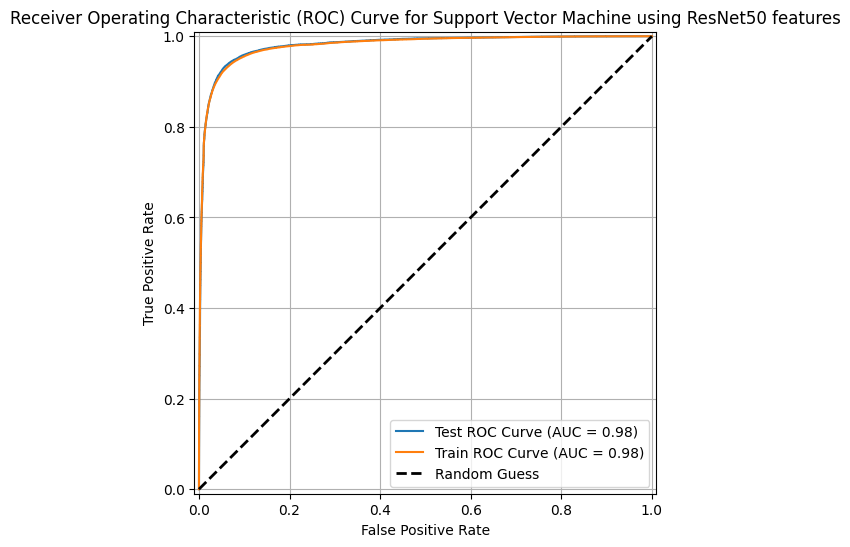

<Figure size 800x600 with 0 Axes>

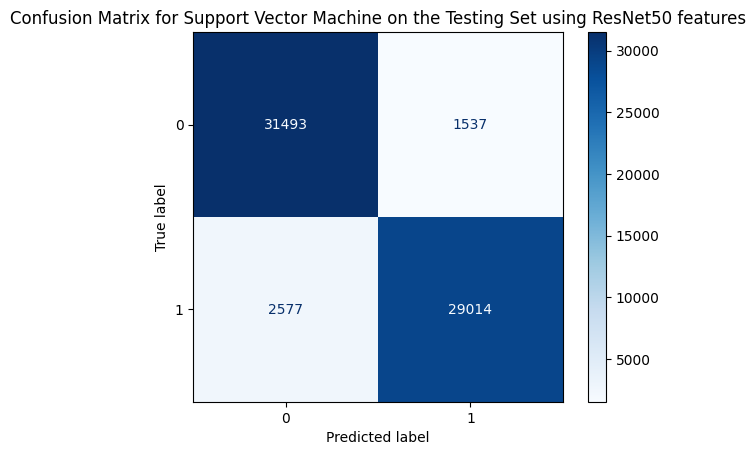

In [ ]:
# Plots for SVM
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot ROC Curve
plt.figure(figsize=(8, 6))

# Get predicted probabilities for the positive class (TESTING SET)
y_pred_proba_test = model_svm.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC (TESTING SET)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_pred_proba_test, pos_label=1)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot the ROC curve (TESTING SET)
roc_display_test = RocCurveDisplay(fpr=fpr_test, tpr=tpr_test, roc_auc=roc_auc_test, estimator_name='SVM (Test)')
roc_display_test.plot(ax=plt.gca(), name='Test ROC Curve')

# Get predicted probabilities for the positive class (TRAINING SET)
y_pred_proba_train = model_svm.predict_proba(X_train)[:, 1]

# Calculate ROC curve and AUC (TRAINING SET)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_proba_train, pos_label=1)
roc_auc_train = auc(fpr_train, tpr_train)

# Plot the ROC curve (TRAINING SET)
roc_display_train = RocCurveDisplay(fpr=fpr_train, tpr=tpr_train, roc_auc=roc_auc_train, estimator_name='SVM (Train)')
roc_display_train.plot(ax=plt.gca(), name='Train ROC Curve')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess') # Add random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Support Vector Machine using {NeuralNetwork} features')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(model_svm, X_test, y_test, cmap=plt.cm.Blues, normalize=None)
cm_display.ax_.set_title(f'Confusion Matrix for Support Vector Machine on the Testing Set using {NeuralNetwork} features')
plt.show()

RF Model

In [ ]:
# Load the Random Forest model
import joblib

rf_model_save_path = f'/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_rf_model_full.joblib'
model_rf = joblib.load(rf_model_save_path)

print(f"Random Forest model loaded successfully from {rf_model_save_path}")

Random Forest model loaded successfully from /content/drive/MyDrive/Colab-Hybrid-Ransomware/ResNet50/ResNet50_rf_model_full.joblib


In [ ]:
# Train the RF
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
import os

# Initialize the Random Forest model
model_rf = RandomForestClassifier(random_state=42)

# Train the Random Forest model
print("Starting Random Forest model training...")
model_rf.fit(X_train, y_train)
print("Random Forest model training complete.")

In [ ]:
# Define the save path for the Random Forest model
rf_model_save_path = f'/content/drive/MyDrive/Colab-Hybrid-Ransomware/{NeuralNetwork}/{NeuralNetwork}_rf_model_full.joblib'

# Save the Random Forest model
joblib.dump(model_rf, rf_model_save_path)

print(f"Random Forest model saved to {rf_model_save_path}")

In [ ]:
# Benchmark the RF
# --- Test Set Metrics ---
y_pred_rf_test = model_rf.predict(X_test)
print("Predictions Made for Test Set")

# Calculate accuracy, precision, recall, and F1 score for test set
accuracy_rf_test = accuracy_score(y_test, y_pred_rf_test)
precision_rf_test = precision_score(y_test, y_pred_rf_test, average='binary', pos_label=1)
recall_rf_test = recall_score(y_test, y_pred_rf_test, average='binary', pos_label=1)
f1_rf_test = f1_score(y_test, y_pred_rf_test, average='binary', pos_label=1)

print(f"Random Forest Model (Test) Accuracy: {accuracy_rf_test:.4f}")
print(f"Random Forest Model (Test) Precision: {precision_rf_test:.4f}")
print(f"Random Forest Model (Test) Recall: {recall_rf_test:.4f}")
print(f"Random Forest Model (Test) F1 Score: {f1_rf_test:.4f}")

# --- Train Set Metrics ---
y_pred_rf_train = model_rf.predict(X_train)
print("\nPredictions Made for Train Set")

# Calculate accuracy, precision, recall, and F1 score for train set
accuracy_rf_train = accuracy_score(y_train, y_pred_rf_train)
precision_rf_train = precision_score(y_train, y_pred_rf_train, average='binary', pos_label=1)
recall_rf_train = recall_score(y_train, y_pred_rf_train, average='binary', pos_label=1)
f1_rf_train = f1_score(y_train, y_pred_rf_train, average='binary', pos_label=1)

print(f"Random Forest Model (Train) Accuracy: {accuracy_rf_train:.4f}")
print(f"Random Forest Model (Train) Precision: {precision_rf_train:.4f}")
print(f"Random Forest Model (Train) Recall: {recall_rf_train:.4f}")
print(f"Random Forest Model (Train) F1 Score: {f1_rf_train:.4f}")

Predictions Made for Test Set
Random Forest Model (Test) Accuracy: 0.9784
Random Forest Model (Test) Precision: 0.9856
Random Forest Model (Test) Recall: 0.9694
Random Forest Model (Test) F1 Score: 0.9774

Predictions Made for Train Set
Random Forest Model (Train) Accuracy: 0.9794
Random Forest Model (Train) Precision: 0.9861
Random Forest Model (Train) Recall: 0.9714
Random Forest Model (Train) F1 Score: 0.9787


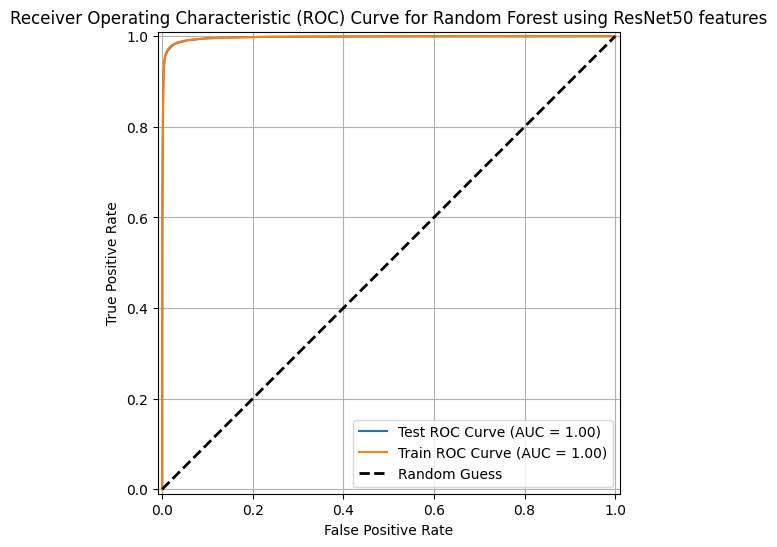

<Figure size 800x600 with 0 Axes>

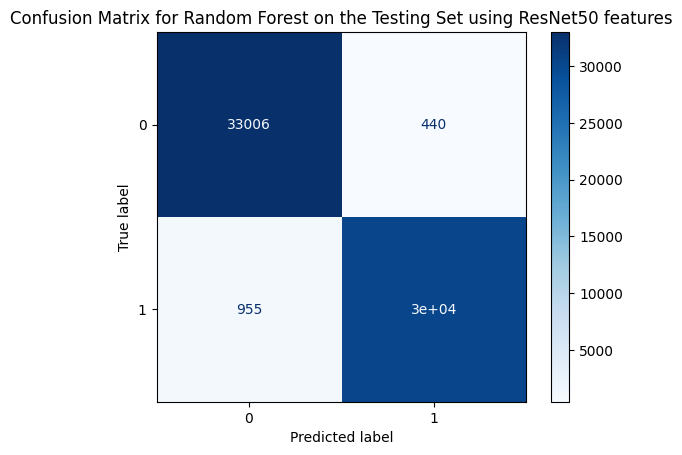

In [ ]:
# Plots for RF
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot ROC Curve
plt.figure(figsize=(8, 6))

# Get predicted probabilities for the positive class (TESTING SET)
y_pred_proba_test = model_rf.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC (TESTING SET)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_pred_proba_test, pos_label=1)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot the ROC curve (TESTING SET)
roc_display_test = RocCurveDisplay(fpr=fpr_test, tpr=tpr_test, roc_auc=roc_auc_test, estimator_name='Random Forest (Test)')
roc_display_test.plot(ax=plt.gca(), name='Test ROC Curve')

# Get predicted probabilities for the positive class (TRAINING SET)
y_pred_proba_train = model_rf.predict_proba(X_train)[:, 1]

# Calculate ROC curve and AUC (TRAINING SET)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_pred_proba_train, pos_label=1)
roc_auc_train = auc(fpr_train, tpr_train)

# Plot the ROC curve (TRAINING SET)
roc_display_train = RocCurveDisplay(fpr=fpr_train, tpr=tpr_train, roc_auc=roc_auc_train, estimator_name='Random Forest (Train)')
roc_display_train.plot(ax=plt.gca(), name='Train ROC Curve')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess') # Add random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for Random Forest using {NeuralNetwork} features')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(model_rf, X_test, y_test, cmap=plt.cm.Blues, normalize=None)
cm_display.ax_.set_title(f'Confusion Matrix for Random Forest on the Testing Set using {NeuralNetwork} features')
plt.show()